In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the Dataset

df = pd.read_csv("GlobalWeatherRepository.csv")

In [3]:
#Checking if any null values

df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143457 entries, 0 to 143456
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       143457 non-null  object 
 1   location_name                 143457 non-null  object 
 2   latitude                      143457 non-null  float64
 3   longitude                     143457 non-null  float64
 4   timezone                      143457 non-null  object 
 5   last_updated_epoch            143457 non-null  int64  
 6   last_updated                  143457 non-null  object 
 7   temperature_celsius           143457 non-null  float64
 8   temperature_fahrenheit        143457 non-null  float64
 9   condition_text                143457 non-null  object 
 10  wind_mph                      143457 non-null  float64
 11  wind_kph                      143457 non-null  float64
 12  wind_degree                   143457 non-nul

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [4]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col]= df[col].fillna(df[col].mean())

In [5]:
# Removing duplicates

df.drop_duplicates(inplace=True)

In [6]:
#converting last_updates ==> to_datetime

df["last_updates"] = pd.to_datetime(df["last_updated"])

In [7]:
#handling outliers

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

## Exploratory Data Analysis

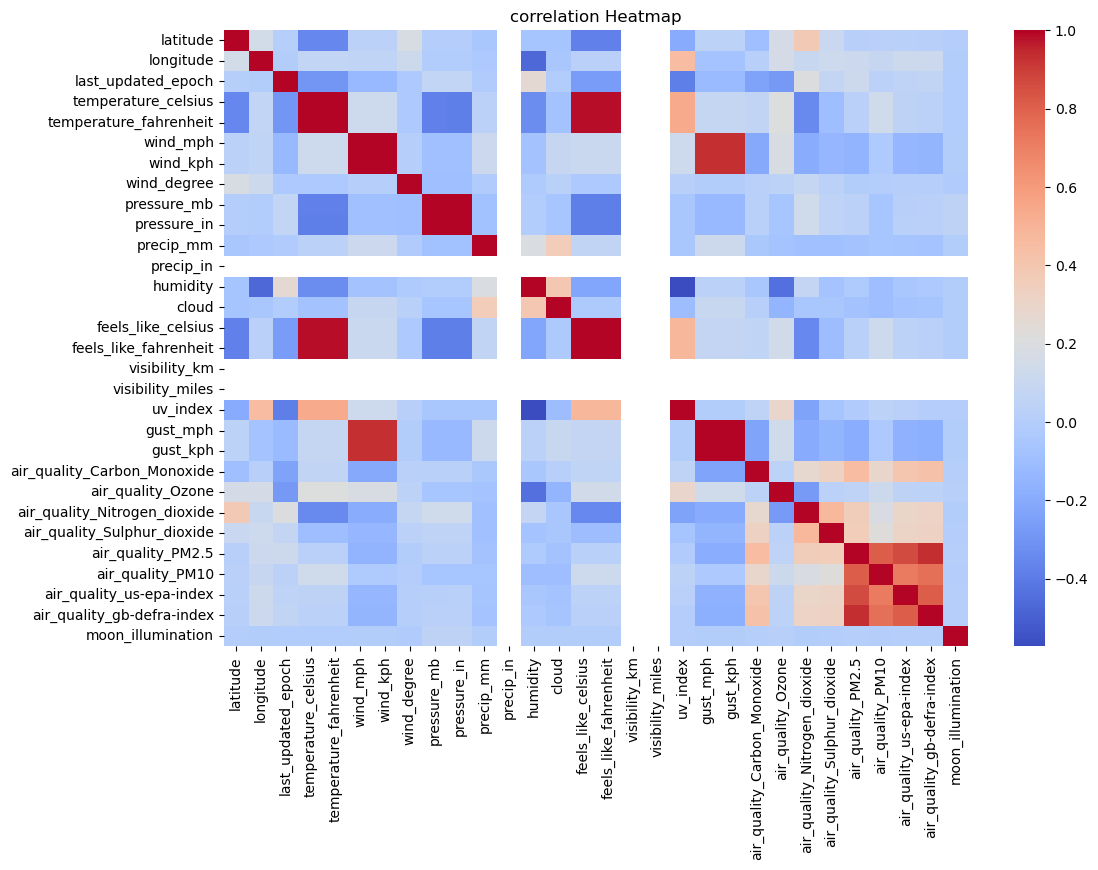

In [9]:
#Correlation heatmap for Data Visualisation

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

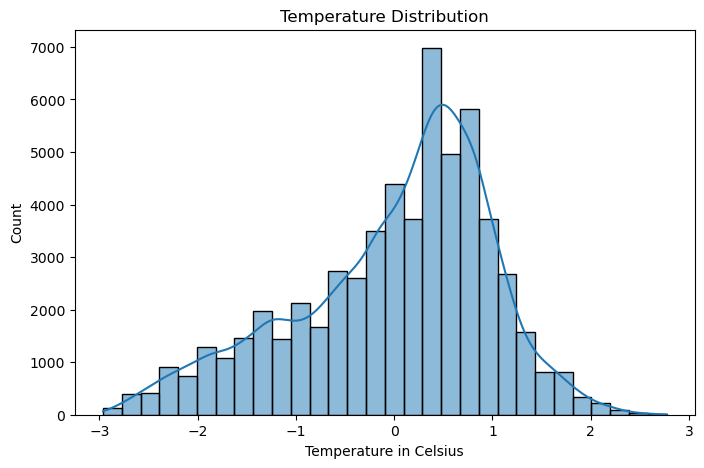

In [10]:
#Temperature distribution
plt.figure(figsize = (8,5))
sns.histplot(df["temperature_celsius"], bins=30, kde=True)
plt.title("Temperature Distribution")
plt.xlabel("Temperature in Celsius")
plt.show()

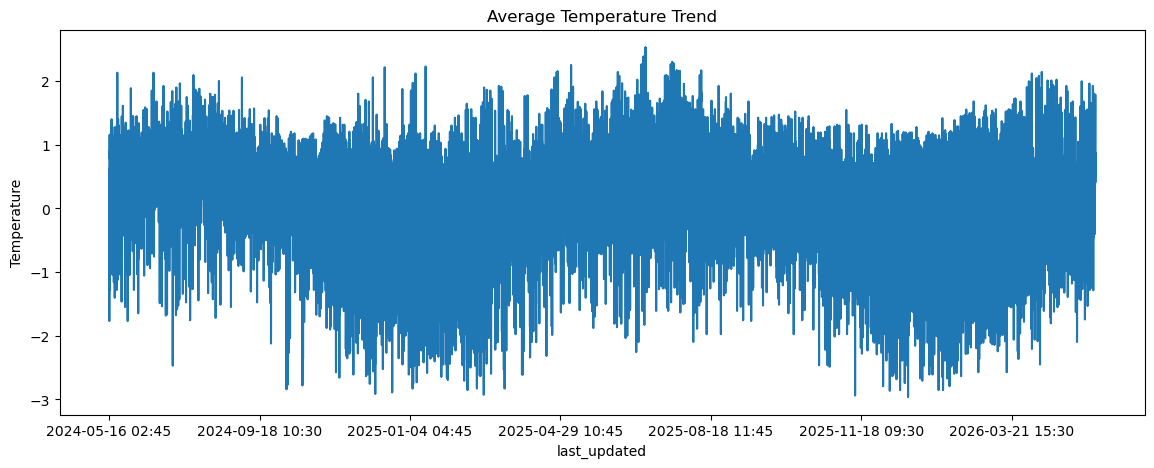

In [11]:
#Temperature trend over time

temp_trend = df.groupby("last_updated")["temperature_celsius"].mean()

plt.figure(figsize=(14,5))
temp_trend.plot()
plt.title("Average Temperature Trend")
plt.ylabel("Temperature")
plt.show()

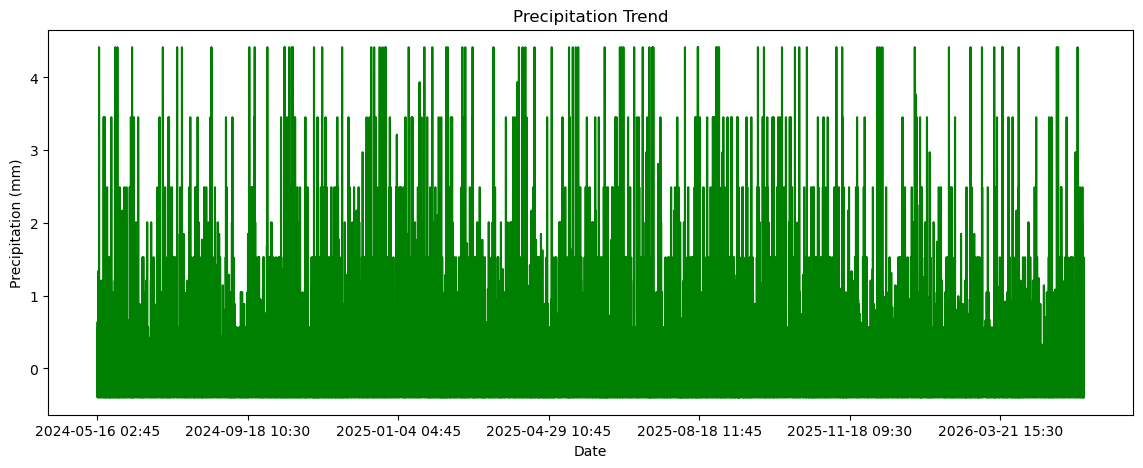

In [12]:
# Precipitation trend

precip_trend = df.groupby('last_updated')['precip_mm'].mean()

plt.figure(figsize=(14,5))

precip_trend.plot(color='green')

plt.title("Precipitation Trend")
plt.ylabel("Precipitation (mm)")
plt.xlabel("Date")

plt.show()

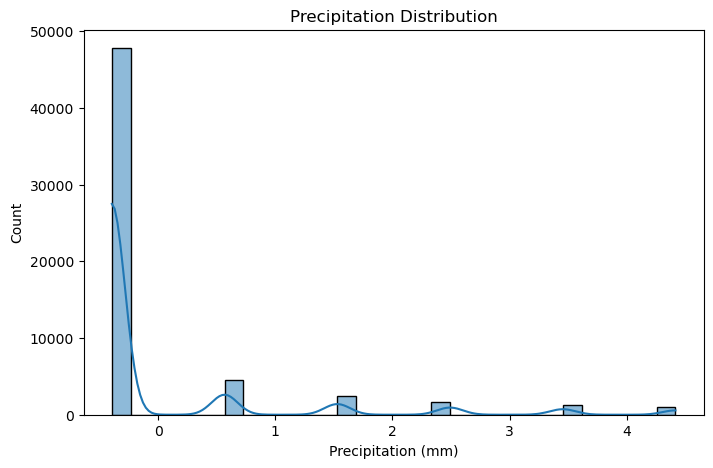

In [13]:
#Precipitation Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['precip_mm'], bins=30, kde=True)
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.show()

In [14]:
#feature selection
features = ["humidity", "wind_kph", "pressure_mb", "precip_mm"]

X = df[features]
y = df["temperature_celsius"]

In [15]:
#Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [16]:
#build Machine Learning Model

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators =100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
#Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE = ",mae)
print("MSE = ",mse)
print("RMSE = ",rmse)
print("r2 Score = ",r2)

MAE =  0.5627012011048778
MSE =  0.6112020211328524
RMSE =  0.781794104053524
r2 Score =  0.38640148935839713


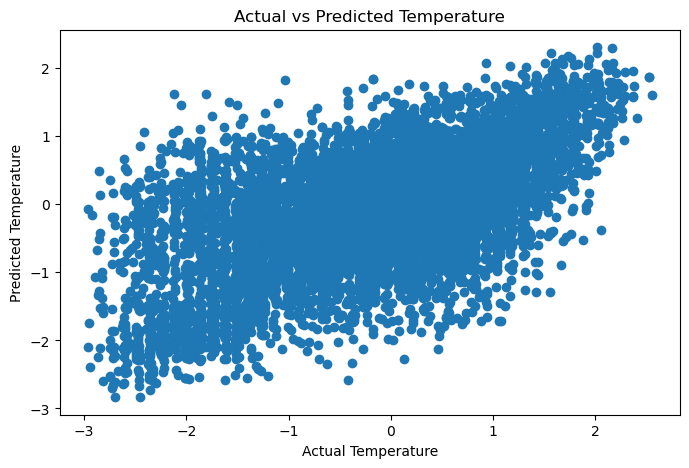

In [20]:
#Actutal VS Predicted

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")

plt.title("Actual vs Predicted Temperature")
plt.show()

## Advanced EDA

In [21]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [22]:
features = ["temperature_celsius","humidity","wind_kph","pressure_mb","precip_mm"]

weather_data = df[features]

In [23]:
#Detect outliers using Z-score

z_scores = np.abs(zscore(weather_data))
outliers_z = (z_scores > 3).any(axis=1)
df["ZScore_Anomaly"] = outliers_z

In [24]:
#Detect outliers using Isolation forest

iso_forest = IsolationForest(
    contamination=0.01,
    random_state=42
)

df["IF_Anomaly"] = iso_forest.fit_predict(weather_data)

In [25]:
print(df["IF_Anomaly"].value_counts())

IF_Anomaly
 1    58007
-1      586
Name: count, dtype: int64


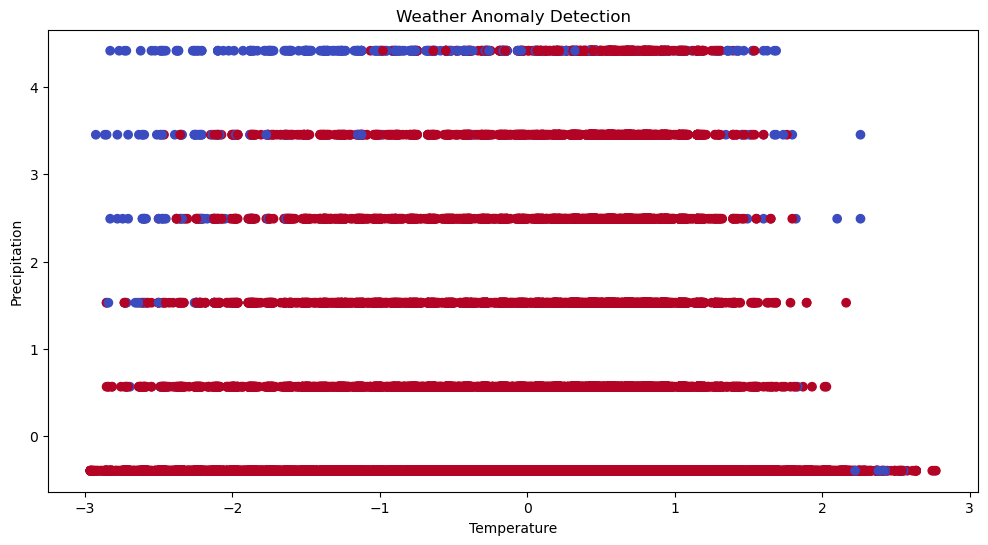

In [26]:
plt.figure(figsize=(12,6))

plt.scatter(df["temperature_celsius"], df["precip_mm"],c=df["IF_Anomaly"],cmap="coolwarm")

plt.xlabel("Temperature")
plt.ylabel("Precipitation")
plt.title("Weather Anomaly Detection")

plt.show()

In [27]:
#feature selection
features = ["humidity", "wind_kph", "pressure_mb", "precip_mm"]

X = df[features]
y = df["temperature_celsius"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [30]:
#Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [31]:
#Train Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

In [32]:
#Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [33]:
#Evaluation

from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    print(f"{name}")
    print("MAE:", mae)
    print("R2 Score:", r2)
    

Linear Regression
MAE: 0.687077291094164
R2 Score: 0.2719561598536363
Decision Tree
MAE: 0.6661292924971778
R2 Score: 0.054132536401546694
Random Forest
MAE: 0.5627012011048778
R2 Score: 0.38640148935839713


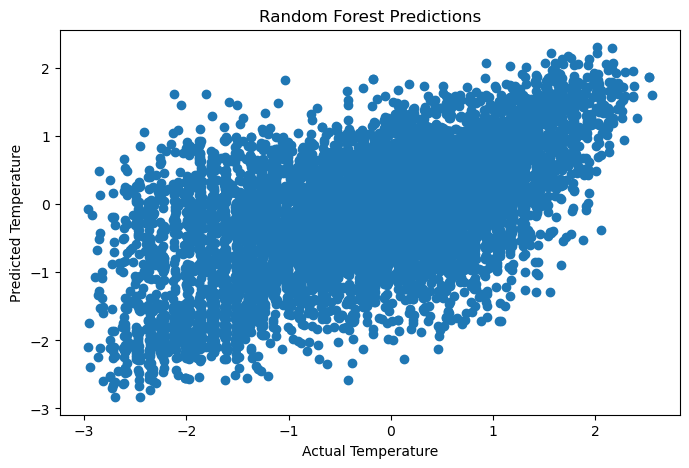

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Random Forest Predictions")
plt.show()